# 🚀 Polymarket BTC Up/Down 5-min — Sistema de Predicción y Backtest

Notebook completo para predecir resoluciones de mercados binarios BTC en Polymarket (ventanas de 5 minutos), generar señales de entrada basadas en **Expected Value neto** y simular una cartera con backtest completo.

---

## 1. Imports y Configuración

Cargamos librerías, fijamos semillas de aleatoriedad y definimos los parámetros globales de trading (stake, capital inicial, umbral EV) y los hiperparámetros del modelo XGBoost.

In [10]:
# ============================================================
# 1. IMPORTS Y CONFIGURACIÓN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
import random

# Machine Learning
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    roc_curve, brier_score_loss, confusion_matrix,
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

# ── Reproducibilidad ────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Parámetros de trading ───────────────────────────────────
STAKE           = 10.0    # USDC por operación
INITIAL_CAPITAL = 1000.0  # Capital inicial (USDC)
EV_THRESHOLD    = 0.05    # Umbral mínimo EV neto (USDC) para operar

# ── Hiperparámetros XGBoost ─────────────────────────────────
XGB_PARAMS = dict(
    n_estimators        = 600,
    max_depth           = 5,
    learning_rate       = 0.04,
    subsample           = 0.80,
    colsample_bytree    = 0.80,
    min_child_weight    = 5,
    gamma               = 0.1,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    use_label_encoder   = False,
    eval_metric         = "logloss",
    random_state        = RANDOM_SEED,
    tree_method         = "hist",
    early_stopping_rounds = 50,
)

# ── Partición temporal ──────────────────────────────────────
TRAIN_FRAC = 0.70  # 70 % de mercados → train
VAL_FRAC   = 0.15  # 15 % validación | 15 % test

print("✅ Imports y configuración listos.")
print(f"   STAKE         = {STAKE} USDC")
print(f"   CAPITAL       = {INITIAL_CAPITAL} USDC")
print(f"   EV_THRESHOLD  = {EV_THRESHOLD} USDC")
print(f"   XGB n_est.    = {XGB_PARAMS['n_estimators']} | depth={XGB_PARAMS['max_depth']} | lr={XGB_PARAMS['learning_rate']}")


✅ Imports y configuración listos.
   STAKE         = 10.0 USDC
   CAPITAL       = 1000.0 USDC
   EV_THRESHOLD  = 0.05 USDC
   XGB n_est.    = 600 | depth=5 | lr=0.04


## 2. Carga de Datos

Si existe el fichero `polymarket_btc_5m.csv` en el directorio de trabajo, se carga directamente. En caso contrario, se **genera un dataset sintético** de 450 mercados con la misma estructura del real (libro de órdenes coherente, resolución ligada al drift BTC, microestructura Binance correlacionada).  
Cambia `DATA_PATH` a la ruta de tu CSV real cuando lo tengas disponible.

In [11]:
# ============================================================
# 2. CARGA DE DATOS
# ============================================================

DATA_PATH = "../dataset_with_resolution.csv"   # <- Cambia aquí tu ruta real


def generate_synthetic_dataset(n_markets=450, seed=42):
    # Genera un DataFrame sintético con la misma estructura que el dataset real.
    # Simula orden book coherente, resolución ligada al drift de BTC y
    # variables de microestructura correlacionadas con el outcome.
    np.random.seed(seed)
    records = []
    BTC_BASE   = 65_000.0
    BASE_TIME  = datetime(2024, 3, 1, 0, 0, 0)
    MARKET_DUR = 300          # 5 min en segundos
    FEE_OPTS   = [20, 25, 30] # bps

    # Precio BTC con random walk entre mercados
    btc_walk = np.concatenate([
        [BTC_BASE],
        BTC_BASE + np.cumsum(np.random.normal(0, 150, n_markets - 1))
    ])

    for i in range(n_markets):
        slug      = f"btc-up-down-5m-{i:05d}"
        open_time = BASE_TIME + timedelta(minutes=5 * i)
        btc_open  = float(btc_walk[i])

        # Drift real del mercado -> determina resolución
        true_drift = float(np.random.normal(0, 0.0014))
        resolution = "up" if true_drift > 0 else "down"

        # Fees fijos por mercado
        up_fee_bps   = int(np.random.choice(FEE_OPTS))
        down_fee_bps = int(np.random.choice(FEE_OPTS))
        fee_rate_up  = up_fee_bps / 10_000
        fee_rate_dn  = down_fee_bps / 10_000

        # Snapshots
        n_snaps  = int(np.random.randint(12, 55))
        pool     = np.arange(5, 295)
        secs_left = np.sort(
            np.random.choice(pool, size=min(n_snaps, len(pool)), replace=False)
        )[::-1]

        for t_left in secs_left:
            elapsed   = MARKET_DUR - t_left
            mkt_prog  = elapsed / MARKET_DUR

            # BTC spot con ruido
            noise    = np.random.normal(0, 0.00025 * np.sqrt(elapsed + 1))
            btc_spot = btc_open * (1 + true_drift * mkt_prog + noise)
            btc_ret  = (btc_spot - btc_open) / btc_open * 100

            # Probabilidad verdadera de UP (ground-truth simulada)
            p_up_true = float(np.clip(
                0.50 + 18 * true_drift + 0.035 * btc_ret
                + np.random.normal(0, 0.015), 0.05, 0.95
            ))
            p_dn_true = 1.0 - p_up_true

            # Libro de órdenes UP
            sp_up     = float(np.random.uniform(0.010, 0.035))
            up_ask_p1 = float(np.clip(p_up_true + sp_up / 2, 0.06, 0.97))
            up_ask_p2 = float(np.clip(up_ask_p1 + np.random.uniform(0.005, 0.012), 0.06, 0.99))
            up_ask_p3 = float(np.clip(up_ask_p2 + np.random.uniform(0.005, 0.012), 0.06, 0.99))
            up_bid_p1 = float(np.clip(p_up_true - sp_up / 2, 0.02, 0.93))
            up_bid_p2 = float(np.clip(up_bid_p1 - np.random.uniform(0.005, 0.012), 0.01, 0.92))
            up_bid_p3 = float(np.clip(up_bid_p2 - np.random.uniform(0.005, 0.012), 0.01, 0.91))
            up_ask_s1 = float(np.random.uniform(25, 350))
            up_ask_s2 = float(np.random.uniform(25, 500))
            up_ask_s3 = float(np.random.uniform(25, 500))
            up_bid_s1 = float(np.random.uniform(25, 350))
            up_bid_s2 = float(np.random.uniform(25, 500))
            up_bid_s3 = float(np.random.uniform(25, 500))

            # Trade opportunity UP
            up_avg_fill = up_ask_p1
            fee_up      = STAKE * fee_rate_up
            shares_up   = STAKE / up_avg_fill
            up_win_net  = shares_up - STAKE - fee_up
            up_loss_net = -(STAKE + fee_up)
            up_break_ev = abs(up_loss_net) / (up_win_net + abs(up_loss_net))

            # Libro de órdenes DOWN
            sp_dn      = float(np.random.uniform(0.010, 0.035))
            dn_ask_p1  = float(np.clip(p_dn_true + sp_dn / 2, 0.06, 0.97))
            dn_ask_p2  = float(np.clip(dn_ask_p1 + np.random.uniform(0.005, 0.012), 0.06, 0.99))
            dn_ask_p3  = float(np.clip(dn_ask_p2 + np.random.uniform(0.005, 0.012), 0.06, 0.99))
            dn_bid_p1  = float(np.clip(p_dn_true - sp_dn / 2, 0.02, 0.93))
            dn_bid_p2  = float(np.clip(dn_bid_p1 - np.random.uniform(0.005, 0.012), 0.01, 0.92))
            dn_bid_p3  = float(np.clip(dn_bid_p2 - np.random.uniform(0.005, 0.012), 0.01, 0.91))
            dn_ask_s1  = float(np.random.uniform(25, 350))
            dn_ask_s2  = float(np.random.uniform(25, 500))
            dn_ask_s3  = float(np.random.uniform(25, 500))
            dn_bid_s1  = float(np.random.uniform(25, 350))
            dn_bid_s2  = float(np.random.uniform(25, 500))
            dn_bid_s3  = float(np.random.uniform(25, 500))

            # Trade opportunity DOWN
            dn_avg_fill = dn_ask_p1
            fee_dn      = STAKE * fee_rate_dn
            shares_dn   = STAKE / dn_avg_fill
            dn_win_net  = shares_dn - STAKE - fee_dn
            dn_loss_net = -(STAKE + fee_dn)
            dn_break_ev = abs(dn_loss_net) / (dn_win_net + abs(dn_loss_net))

            # Binance microestructura
            bid_v10 = float(np.random.uniform(60, 420))
            ask_v10 = float(np.random.uniform(60, 420))
            ob_imb  = float(np.clip(
                (bid_v10 - ask_v10) / (bid_v10 + ask_v10)
                + np.random.normal(true_drift * 8, 0.08), -1, 1
            ))
            mid_price = float(btc_spot + np.random.normal(0, 0.4))
            spread_b  = float(np.random.uniform(0.1, 1.8))

            # Retornos por ventana
            ret_1m  = float(np.random.normal(true_drift * 0.18, 0.0007))
            ret_3m  = float(np.random.normal(true_drift * 0.50, 0.0013))
            ret_5m  = float(np.random.normal(true_drift * 0.80, 0.0020))
            ret_10m = float(np.random.normal(true_drift * 0.60, 0.0030))

            # EMAs
            ema_3   = float(btc_spot * (1 + np.random.normal( true_drift * 0.08, 0.00010)))
            ema_6   = float(btc_spot * (1 + np.random.normal( true_drift * 0.04, 0.00018)))
            ema_12  = float(btc_spot * (1 + np.random.normal( 0.0,               0.00028)))
            ema_24  = float(btc_spot * (1 + np.random.normal(-true_drift * 0.04, 0.00040)))
            ema_ratio   = float(ema_3 / ema_12)
            price_ema12 = float(btc_spot / ema_12)

            # Volumen
            vol_1m = float(abs(np.random.normal(200 + abs(true_drift) * 40_000, 45)))
            vol_3m = float(vol_1m * np.random.uniform(2.6, 3.4))
            vol_5m = float(vol_3m * np.random.uniform(1.5, 1.9))

            # Volatilidad
            vola_3m = float(abs(np.random.normal(0.0009 + abs(true_drift), 0.0003)))
            vola_5m = float(abs(np.random.normal(0.0011 + abs(true_drift), 0.0004)))

            # Trade flow
            buy_v  = float(abs(np.random.normal(5 + true_drift * 450, 2.0)))
            sell_v = float(abs(np.random.normal(5 - true_drift * 450, 2.0)))
            t_imb  = float(np.clip((buy_v - sell_v) / (buy_v + sell_v + 1e-9), -1, 1))

            records.append({
                "timestamp":               open_time + timedelta(seconds=float(elapsed)),
                "market_slug":             slug,
                "seconds_left":            float(t_left),
                "market_progress":         float(mkt_prog),
                "resolution":              resolution,
                "btc_spot":                float(btc_spot),
                "btc_price_market_open":   float(btc_open),
                "btc_return_since_open":   float(btc_ret),
                "up_bid_p_1": up_bid_p1, "up_bid_s_1": up_bid_s1,
                "up_bid_p_2": up_bid_p2, "up_bid_s_2": up_bid_s2,
                "up_bid_p_3": up_bid_p3, "up_bid_s_3": up_bid_s3,
                "up_ask_p_1": up_ask_p1, "up_ask_s_1": up_ask_s1,
                "up_ask_p_2": up_ask_p2, "up_ask_s_2": up_ask_s2,
                "up_ask_p_3": up_ask_p3, "up_ask_s_3": up_ask_s3,
                "down_bid_p_1": dn_bid_p1, "down_bid_s_1": dn_bid_s1,
                "down_bid_p_2": dn_bid_p2, "down_bid_s_2": dn_bid_s2,
                "down_bid_p_3": dn_bid_p3, "down_bid_s_3": dn_bid_s3,
                "down_ask_p_1": dn_ask_p1, "down_ask_s_1": dn_ask_s1,
                "down_ask_p_2": dn_ask_p2, "down_ask_s_2": dn_ask_s2,
                "down_ask_p_3": dn_ask_p3, "down_ask_s_3": dn_ask_s3,
                "up_fee_bps":      float(up_fee_bps),
                "down_fee_bps":    float(down_fee_bps),
                "up_avg_fill":     float(up_avg_fill),
                "up_win_net":      float(up_win_net),
                "up_loss_net":     float(up_loss_net),
                "up_break_even":   float(up_break_ev),
                "down_avg_fill":   float(dn_avg_fill),
                "down_win_net":    float(dn_win_net),
                "down_loss_net":   float(dn_loss_net),
                "down_break_even": float(dn_break_ev),
                "bid_volume_10":       float(bid_v10),
                "ask_volume_10":       float(ask_v10),
                "orderbook_imbalance": float(ob_imb),
                "mid_price":           float(mid_price),
                "spread":              float(spread_b),
                "ret_1m":  ret_1m,  "ret_3m":  ret_3m,
                "ret_5m":  ret_5m,  "ret_10m": ret_10m,
                "ema_3":  ema_3,    "ema_6":  ema_6,
                "ema_12": ema_12,   "ema_24": ema_24,
                "ema_ratio":      ema_ratio,
                "price_vs_ema12": price_ema12,
                "volume_1m":  vol_1m, "volume_3m": vol_3m, "volume_5m": vol_5m,
                "volatility_3m": vola_3m, "volatility_5m": vola_5m,
                "buy_volume_last200":  buy_v,
                "sell_volume_last200": sell_v,
                "trade_imbalance":     t_imb,
            })

    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["timestamp", "market_slug"]).reset_index(drop=True)
    return df


# ── Carga / generación ───────────────────────────────────────
if os.path.exists(DATA_PATH):
    print(f"Cargando datos reales: {DATA_PATH}")
    df_raw = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
else:
    print("CSV no encontrado -> generando datos sinteticos para demo...")
    df_raw = generate_synthetic_dataset(n_markets=450, seed=RANDOM_SEED)

print(f"\nDataset cargado:")
print(f"  Filas:             {len(df_raw):,}")
print(f"  Columnas:          {df_raw.shape[1]}")
print(f"  Mercados unicos:   {df_raw['market_slug'].nunique():,}")
print(f"  Rango temporal:    {df_raw['timestamp'].min()} -> {df_raw['timestamp'].max()}")
snaps_desc = df_raw.groupby("market_slug").size().describe()
print(f"  Snapshots/mercado: mean={snaps_desc['mean']:.1f} min={snaps_desc['min']:.0f} max={snaps_desc['max']:.0f}")
print(f"\n  Distribucion resolucion:")
print(df_raw["resolution"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")
df_raw.head(3)


Cargando datos reales: ../dataset_with_resolution.csv

Dataset cargado:
  Filas:             74,269
  Columnas:          66
  Mercados unicos:   773
  Rango temporal:    2026-03-19 16:15:55.759706+00:00 -> 2026-03-22 08:35:49.100622+00:00
  Snapshots/mercado: mean=96.1 min=16 max=99

  Distribucion resolucion:
resolution
down    50.37%
up      49.63%
Name: proportion, dtype: str


,timestamp,market_slug,seconds_left,market_progress,btc_spot,btc_price_market_open,btc_return_since_open,up_bid_p_1,up_bid_s_1,up_ask_p_1,up_ask_s_1,up_bid_p_2,up_bid_s_2,up_ask_p_2,up_ask_s_2,up_bid_p_3,up_bid_s_3,up_ask_p_3,up_ask_s_3,down_bid_p_1,down_bid_s_1,down_ask_p_1,down_ask_s_1,down_bid_p_2,down_bid_s_2,down_ask_p_2,down_ask_s_2,down_bid_p_3,down_bid_s_3,down_ask_p_3,...,up_break_even,down_avg_fill,down_win_net,down_loss_net,down_break_even,market_liquid,bid_volume_10,ask_volume_10,orderbook_imbalance,mid_price,spread,ret_1m,ret_3m,ret_5m,ret_10m,ema_3,ema_6,ema_12,ema_24,ema_ratio,price_vs_ema12,volume_1m,volume_3m,volume_5m,volatility_3m,volatility_5m,buy_volume_last200,sell_volume_last200,trade_imbalance,resolution
0,2026-03-19 16:15:55.759706+00:00,btc-updown-5m-1773936900,246,0.1800,69365.4200,69365.4200,0.0000,0.5900,13.1800,0.6000,651.4700,0.5800,61.8200,0.6100,837.4500,0.5700,140.0000,0.6200,1226.2500,0.4000,651.4700,0.4200,40.0800,0.3900,812.4500,0.4300,145.0000,0.3800,1226.2500,0.4400,...,0.6006,0.4200,13.7995,-10.0100,0.4204,1.0000,7.5313,1.0054,0.7644,69365.4150,0.0100,0.0007,0.0013,0.0010,-0.0005,69306.6355,69300.7648,69316.7306,69319.5883,0.9999,1.0003,18.8987,56.5347,84.1646,0.0005,0.0005,0.0196,0.1045,-0.6846,down
1,2026-03-19 16:15:58.879491+00:00,btc-updown-5m-1773936900,242,0.1933,69355.4100,69365.4200,-0.0001,0.5900,50.1200,0.6000,347.6600,0.5800,136.0000,0.6100,1548.4900,0.5700,83.0000,0.6200,995.0000,0.4000,422.6600,0.4100,40.1200,0.3900,1533.4900,0.4200,136.0000,0.3800,1075.0000,0.4300,...,0.6006,0.4100,14.3802,-10.0100,0.4104,1.0000,0.3497,8.2914,-0.9191,69354.6550,0.0100,0.0007,0.0013,0.0010,-0.0005,69306.6355,69300.7648,69316.7306,69319.5883,0.9999,1.0003,18.8987,56.5347,84.1646,0.0005,0.0005,0.0698,0.1630,-0.4001,down
2,2026-03-19 16:16:01.972372+00:00,btc-updown-5m-1773936900,239,0.2033,69354.6500,69365.4200,-0.0002,0.5500,629.0000,0.5600,257.6100,0.5400,1043.0000,0.5700,949.0800,0.5300,706.0000,0.5800,595.0000,0.4400,256.8800,0.4500,478.5000,0.4300,969.0800,0.4600,873.0000,0.4200,600.0000,0.4700,...,0.5606,0.4500,12.2122,-10.0100,0.4505,1.0000,2.3923,1.9123,0.1115,69354.6550,0.0100,0.0002,0.0016,0.0012,0.0001,69330.6477,69316.1634,69322.5659,69322.3968,1.0001,1.0005,13.5921,46.8090,83.6352,0.0003,0.0005,0.0543,0.2087,-0.5871,down


## 3. Limpieza y Validación de Datos

Pasos:
1. Detectar y reemplazar `inf` / `-inf`.
2. Eliminar filas con NaN en columnas críticas.
3. Rellenar NaN residuales con la mediana.
4. Validar que los precios del libro están en (0, 1).
5. Validar que `resolution` ∈ {`up`, `down`}.
6. Ordenar temporalmente.

In [12]:
# ============================================================
# 3. LIMPIEZA Y VALIDACIÓN
# ============================================================

df = df_raw.copy()

print("=" * 60)
print("3.1  NaN por columna")
print("=" * 60)
nan_report = df.isnull().sum()
nan_cols   = nan_report[nan_report > 0]
if len(nan_cols):
    print(nan_cols)
else:
    print("  Sin NaNs encontrados")

# Reemplazar infinitos
num_cols  = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[num_cols]).sum().sum()
print(f"\n3.2  Infinitos encontrados: {inf_count}")
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

# Eliminar filas con NaN en columnas criticas
CRITICAL_COLS = [
    "resolution", "seconds_left", "market_progress",
    "up_ask_p_1", "down_ask_p_1",
    "up_win_net", "up_loss_net", "up_break_even",
    "down_win_net", "down_loss_net", "down_break_even",
    "btc_spot", "btc_return_since_open",
]
before = len(df)
df     = df.dropna(subset=CRITICAL_COLS)
print(f"3.3  Filas eliminadas (NaN criticos): {before - len(df)}")

# Rellenar NaN restantes con mediana por columna
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Validaciones de rango: precios del libro deben estar en (0, 1)
price_cols  = [c for c in df.columns if "_ask_p_" in c or "_bid_p_" in c]
bad_price   = ((df[price_cols] <= 0) | (df[price_cols] >= 1)).any(axis=1)
print(f"3.4  Filas con precios fuera de (0,1): {bad_price.sum()}")
df = df[~bad_price]

# Validar resolucion
valid_res = df["resolution"].isin(["up", "down"])
print(f"3.5  Filas con resolucion invalida: {(~valid_res).sum()}")
df = df[valid_res].copy()

# Validar market_progress en [0, 1]
df = df[(df["market_progress"] >= 0) & (df["market_progress"] <= 1)].copy()

# Ordenar
df = df.sort_values(
    ["timestamp", "market_slug", "seconds_left"],
    ascending=[True, True, False]
).reset_index(drop=True)

print(f"\nDataset limpio: {len(df):,} filas | {df['market_slug'].nunique():,} mercados")

# Estadisticas de variables clave
print("\n3.6  Estadisticas de variables clave:")
key_cols = [
    "seconds_left", "market_progress", "btc_return_since_open",
    "up_avg_fill", "down_avg_fill", "up_break_even", "down_break_even",
    "orderbook_imbalance", "trade_imbalance", "ret_5m",
]
df[key_cols].describe().round(4)


3.1  NaN por columna
up_bid_p_1             2737
up_bid_s_1             2737
up_ask_p_1             2307
up_ask_s_1             2307
up_bid_p_2             3838
up_bid_s_2             3838
up_ask_p_2             3290
up_ask_s_2             3290
up_bid_p_3             4845
up_bid_s_3             4845
up_ask_p_3             4258
up_ask_s_3             4258
down_bid_p_1           2312
down_bid_s_1           2312
down_ask_p_1           2736
down_ask_s_1           2736
down_bid_p_2           3300
down_bid_s_2           3300
down_ask_p_2           3852
down_ask_s_2           3852
down_bid_p_3           4258
down_bid_s_3           4258
down_ask_p_3           4853
down_ask_s_3           4853
up_avg_fill            2307
up_win_net             2307
up_loss_net            2307
up_break_even          2307
down_avg_fill          2736
down_win_net           2736
down_loss_net          2736
down_break_even        2736
ema_12                    1
ema_24                    1
ema_ratio                 1

,seconds_left,market_progress,btc_return_since_open,up_avg_fill,down_avg_fill,up_break_even,down_break_even,orderbook_imbalance,trade_imbalance,ret_5m
count,69225.0000,69225.0000,69225.0000,69225.0000,69225.0000,69225.0000,69225.0000,69225.0000,69225.0000,69225.0000
mean,159.4424,0.4685,-0.0000,0.5065,0.5097,0.5070,0.5102,-0.0272,0.0238,0.0000
std,82.6602,0.2755,0.0007,0.2572,0.2572,0.2575,0.2575,0.6462,0.6700,0.0012
min,1.0000,0.0000,-0.0093,0.0039,0.0020,0.0039,0.0020,-0.9998,-1.0000,-0.0087
25%,90.0000,0.2300,-0.0003,0.3287,0.3300,0.3291,0.3303,-0.6485,-0.5996,-0.0005
50%,161.0000,0.4633,0.0000,0.5100,0.5000,0.5105,0.5005,-0.0357,0.0340,0.0000
75%,231.0000,0.7000,0.0003,0.6900,0.6900,0.6907,0.6907,0.5863,0.6573,0.0005
max,300.0000,0.9967,0.0063,0.9990,0.9990,1.0000,1.0000,0.9997,1.0000,0.0061


## 4. Feature Engineering

Creamos features derivadas a partir de las variables del dataset. **No se usa ninguna variable futura** — todo se calcula con datos disponibles en el momento del snapshot.

Grupos de features generados:
- **Microestructura UP/DOWN**: spread, mid-price, profundidad, desequilibrio de liquidez.
- **Precio implícito**: vig del mercado, divergencia UP vs DOWN.
- **Ratios EMA**: alineación de corto/medio/largo plazo.
- **Aceleración del precio**: diferencias entre retornos de distintas ventanas.
- **Acuerdo de señales**: correlación entre order-book de BTC y retorno.
- **Variables temporales**: `log(seconds_left)`, `time_pressure`, interacciones con `market_progress`.
- **Ratios de volumen y volatilidad relativa**.
- **Edge sobre break-even** y ROI estimado.
- **`direction_score`**: score compuesto ponderado de momentum.

In [13]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================
# Todas las features se calculan usando SOLO informacion disponible
# en el momento del snapshot (sin look-ahead).

fe = df.copy()

# ── 4.1 Microestructura UP ──────────────────────────────────
fe["up_spread"]        = fe["up_ask_p_1"] - fe["up_bid_p_1"]
fe["up_mid_price"]     = (fe["up_ask_p_1"] + fe["up_bid_p_1"]) / 2
fe["up_depth_ask"]     = fe["up_ask_s_1"] + fe["up_ask_s_2"] + fe["up_ask_s_3"]
fe["up_depth_bid"]     = fe["up_bid_s_1"] + fe["up_bid_s_2"] + fe["up_bid_s_3"]
fe["up_liq_imbalance"] = (
    (fe["up_depth_bid"] - fe["up_depth_ask"])
    / (fe["up_depth_bid"] + fe["up_depth_ask"] + 1e-9)
)

# ── 4.2 Microestructura DOWN ────────────────────────────────
fe["down_spread"]        = fe["down_ask_p_1"] - fe["down_bid_p_1"]
fe["down_mid_price"]     = (fe["down_ask_p_1"] + fe["down_bid_p_1"]) / 2
fe["down_depth_ask"]     = fe["down_ask_s_1"] + fe["down_ask_s_2"] + fe["down_ask_s_3"]
fe["down_depth_bid"]     = fe["down_bid_s_1"] + fe["down_bid_s_2"] + fe["down_bid_s_3"]
fe["down_liq_imbalance"] = (
    (fe["down_depth_bid"] - fe["down_depth_ask"])
    / (fe["down_depth_bid"] + fe["down_depth_ask"] + 1e-9)
)

# ── 4.3 Precio implicito vs mercado ─────────────────────────
# up_ask + down_ask > 1  →  vig del mercado (lo que paga la casa)
fe["market_vig"]       = fe["up_ask_p_1"] + fe["down_ask_p_1"] - 1.0
fe["implied_up_from_dn"] = 1.0 - fe["down_ask_p_1"]
fe["up_dn_divergence"] = fe["up_ask_p_1"] - fe["implied_up_from_dn"]

# ── 4.4 Ratios de EMA y alineacion ──────────────────────────
fe["ema_3_vs_6"]      = fe["ema_3"]  / (fe["ema_6"]  + 1e-9) - 1.0
fe["ema_6_vs_12"]     = fe["ema_6"]  / (fe["ema_12"] + 1e-9) - 1.0
fe["ema_12_vs_24"]    = fe["ema_12"] / (fe["ema_24"] + 1e-9) - 1.0
fe["ema_trend_score"] = (
    (fe["ema_3"]  > fe["ema_6"] ).astype(int)
    + (fe["ema_6"]  > fe["ema_12"]).astype(int)
    + (fe["ema_12"] > fe["ema_24"]).astype(int)
)   # 0-3: cuantos EMA estan alineados al alza

# ── 4.5 Aceleracion del precio ──────────────────────────────
fe["btc_accel_short"]  = fe["ret_1m"] - fe["ret_3m"] / 3.0
fe["btc_accel_medium"] = fe["ret_3m"] / 3.0 - fe["ret_5m"] / 5.0

# ── 4.6 Acuerdo entre señales ───────────────────────────────
fe["ob_btc_agreement"]   = fe["orderbook_imbalance"] * np.sign(fe["btc_return_since_open"] + 1e-9)
fe["flow_btc_agreement"] = fe["trade_imbalance"]     * np.sign(fe["btc_return_since_open"] + 1e-9)

# ── 4.7 Variables temporales ─────────────────────────────────
fe["seconds_left_log"] = np.log1p(fe["seconds_left"])
fe["time_pressure"]    = 1.0 - fe["market_progress"]

# Interacciones con el progreso del mercado
fe["ret_x_prog"]    = fe["btc_return_since_open"] * fe["market_progress"]
fe["ob_imb_x_prog"] = fe["orderbook_imbalance"]   * fe["market_progress"]

# ── 4.8 Ratios de volumen ────────────────────────────────────
fe["vol_concentration"] = fe["volume_1m"] / (fe["volume_5m"] + 1e-9)
fe["vol_1m_3m_ratio"]   = fe["volume_1m"] / (fe["volume_3m"] / 3.0 + 1e-9)

# ── 4.9 Volatilidad relativa ─────────────────────────────────
fe["vola_ratio"] = fe["volatility_3m"] / (fe["volatility_5m"] + 1e-9)
fe["vola_x_ret"] = fe["volatility_5m"] * abs(fe["ret_5m"])

# ── 4.10 Edge sobre break-even y ROI estimado ───────────────
fe["up_edge_over_be"]  = fe["up_mid_price"]   - fe["up_break_even"]
fe["dn_edge_over_be"]  = fe["down_mid_price"] - fe["down_break_even"]
fe["up_roi_estimate"]  = fe["up_win_net"]     / (STAKE + 1e-9)
fe["dn_roi_estimate"]  = fe["down_win_net"]   / (STAKE + 1e-9)

# ── 4.11 Score de direccion compuesto ───────────────────────
# Pesos redistribuidos al eliminar ret_30s (no disponible en dataset real):
# ret_1m recibe más peso por ser la señal de momentum más corta disponible.
fe["direction_score"] = (
    np.sign(fe["ret_1m"])  * 0.40
    + np.sign(fe["ret_3m"])  * 0.25
    + np.sign(fe["ret_5m"])  * 0.20
    + np.sign(fe["orderbook_imbalance"]) * 0.15
)

# Reemplazar infinitos generados por ratios
new_num = fe.select_dtypes(include=[np.number]).columns
fe[new_num] = fe[new_num].replace([np.inf, -np.inf], np.nan).fillna(0)

# ── Lista de features para el modelo ────────────────────────
EXCLUDE_COLS = {
    "timestamp", "market_slug", "resolution",
    # EMAs brutas (capturadas con ratios)
    "ema_3", "ema_6", "ema_12", "ema_24",
    # Precio BTC absoluto
    "btc_spot", "btc_price_market_open", "mid_price",
    # Book sizes brutas (capturadas en depth)
    "up_bid_s_1", "up_bid_s_2", "up_bid_s_3",
    "up_ask_s_1", "up_ask_s_2", "up_ask_s_3",
    "down_bid_s_1", "down_bid_s_2", "down_bid_s_3",
    "down_ask_s_1", "down_ask_s_2", "down_ask_s_3",
    # Flujo bruto (capturado en trade_imbalance)
    "buy_volume_last200", "sell_volume_last200",
    # Precios de fill (usados para calcular win/loss, no como feature)
    "up_avg_fill", "down_avg_fill",
    # Target y split
    "y", "split",
}

FEATURE_COLS = [
    c for c in fe.columns
    if c not in EXCLUDE_COLS
    and fe[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]
]

print(f"Feature engineering completado.")
print(f"  Total features: {len(FEATURE_COLS)}")
new_feats = [c for c in FEATURE_COLS if c not in df_raw.columns]
print(f"\n  Nuevas features generadas ({len(new_feats)}):")
for f in new_feats:
    print(f"    {f}")


Feature engineering completado.
  Total features: 74

  Nuevas features generadas (34):
    up_spread
    up_mid_price
    up_depth_ask
    up_depth_bid
    up_liq_imbalance
    down_spread
    down_mid_price
    down_depth_ask
    down_depth_bid
    down_liq_imbalance
    market_vig
    implied_up_from_dn
    up_dn_divergence
    ema_3_vs_6
    ema_6_vs_12
    ema_12_vs_24
    ema_trend_score
    btc_accel_short
    btc_accel_medium
    ob_btc_agreement
    flow_btc_agreement
    seconds_left_log
    time_pressure
    ret_x_prog
    ob_imb_x_prog
    vol_concentration
    vol_1m_3m_ratio
    vola_ratio
    vola_x_ret
    up_edge_over_be
    dn_edge_over_be
    up_roi_estimate
    dn_roi_estimate
    direction_score


## 5. Definición del Target

```
y = 1  →  resolución UP
y = 0  →  resolución DOWN
```
Visualizamos la distribución del target y el retorno BTC desde apertura desglosado por clase.

Distribucion del target:
  UP   (y=1): 34,546  (49.9%)
  DOWN (y=0): 34,679  (50.1%)

  Por mercado:
  UP  : 386 (49.9%)
  DOWN: 387 (50.1%)


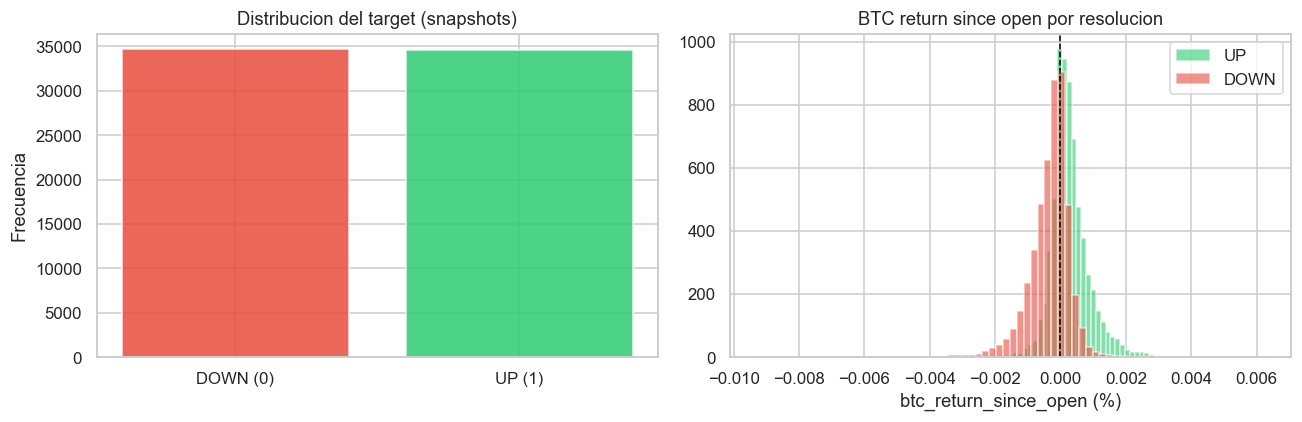

In [14]:
# ============================================================
# 5. DEFINICIÓN DEL TARGET
# ============================================================

fe["y"] = (fe["resolution"] == "up").astype(int)

vc = fe["y"].value_counts()
print("Distribucion del target:")
print(f"  UP   (y=1): {vc.get(1, 0):,}  ({vc.get(1, 0)/len(fe)*100:.1f}%)")
print(f"  DOWN (y=0): {vc.get(0, 0):,}  ({vc.get(0, 0)/len(fe)*100:.1f}%)")

per_market = fe.groupby("market_slug")["y"].first()
mc = per_market.value_counts()
print(f"\n  Por mercado:")
print(f"  UP  : {mc.get(1, 0)} ({mc.get(1, 0)/len(per_market)*100:.1f}%)")
print(f"  DOWN: {mc.get(0, 0)} ({mc.get(0, 0)/len(per_market)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["DOWN (0)", "UP (1)"], [vc.get(0, 0), vc.get(1, 0)],
            color=["#e74c3c", "#2ecc71"], alpha=0.85)
axes[0].set_title("Distribucion del target (snapshots)")
axes[0].set_ylabel("Frecuencia")

for cls, color, label in [(1, "#2ecc71", "UP"), (0, "#e74c3c", "DOWN")]:
    axes[1].hist(fe[fe["y"] == cls]["btc_return_since_open"],
                 bins=60, alpha=0.6, color=color, label=label, density=True)
axes[1].axvline(0, color="black", linestyle="--", lw=1)
axes[1].set_title("BTC return since open por resolucion")
axes[1].set_xlabel("btc_return_since_open (%)")
axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Split Temporal por Mercado (Anti-Leakage)

**Estrategia robusta sin data leakage:**
1. Tomamos el primer timestamp de cada `market_slug`.
2. Ordenamos mercados cronológicamente.
3. Asignamos: primeros 70 % → **train**, siguientes 15 % → **validación**, últimos 15 % → **test**.
4. Todos los snapshots de un mercado van al **mismo** split.

Se verifica con `assert` que no hay ningún mercado compartido entre splits.

Split temporal por mercado

TRAIN         mercados= 541  snapshots=48,364  UP%=50.3%  [2026-03-19 -> 2026-03-21]

VALIDATION    mercados= 115  snapshots=10,479  UP%=51.7%  [2026-03-21 -> 2026-03-21]

TEST          mercados= 117  snapshots=10,382  UP%=46.3%  [2026-03-21 -> 2026-03-22]

Sin solapamiento de mercados entre splits (anti-leakage verificado)


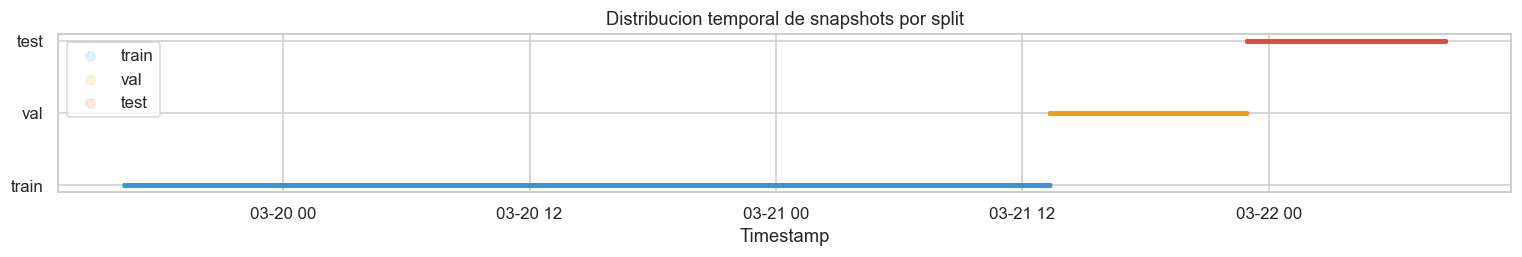

In [15]:
# ============================================================
# 6. SPLIT TEMPORAL POR MERCADO (anti-leakage)
# ============================================================
# Estrategia:
#   1. Primer timestamp de cada mercado -> orden cronologico
#   2. Primeros TRAIN_FRAC% de mercados -> train
#   3. Siguientes VAL_FRAC% -> validacion
#   4. Resto -> test
# Todos los snapshots de un mercado van al mismo split.

market_first_ts = (
    fe.groupby("market_slug")["timestamp"].min()
    .sort_values()
    .reset_index()
    .rename(columns={"timestamp": "first_ts"})
)
n_markets = len(market_first_ts)
n_train   = int(n_markets * TRAIN_FRAC)
n_val     = int(n_markets * VAL_FRAC)

train_markets = set(market_first_ts.iloc[:n_train]["market_slug"])
val_markets   = set(market_first_ts.iloc[n_train : n_train + n_val]["market_slug"])
test_markets  = set(market_first_ts.iloc[n_train + n_val :]["market_slug"])

def assign_split(slug):
    if slug in train_markets: return "train"
    if slug in val_markets:   return "val"
    return "test"

fe["split"] = fe["market_slug"].map(assign_split)

df_train = fe[fe["split"] == "train"].copy()
df_val   = fe[fe["split"] == "val"].copy()
df_test  = fe[fe["split"] == "test"].copy()

X_train = df_train[FEATURE_COLS]; y_train = df_train["y"]
X_val   = df_val[FEATURE_COLS];   y_val   = df_val["y"]
X_test  = df_test[FEATURE_COLS];  y_test  = df_test["y"]

print("=" * 58)
print("Split temporal por mercado")
print("=" * 58)
for name, df_s, n_m in [
    ("TRAIN",      df_train, len(train_markets)),
    ("VALIDATION", df_val,   len(val_markets)),
    ("TEST",       df_test,  len(test_markets)),
]:
    pct_up = df_s["y"].mean() * 100
    ts_min = df_s["timestamp"].min().date()
    ts_max = df_s["timestamp"].max().date()
    print(f"\n{name:12s}  mercados={n_m:4d}  snapshots={len(df_s):6,}  "
          f"UP%={pct_up:.1f}%  [{ts_min} -> {ts_max}]")

# Verificar no solapamiento
assert train_markets.isdisjoint(val_markets),  "LEAKAGE: train y val comparten mercados!"
assert train_markets.isdisjoint(test_markets), "LEAKAGE: train y test comparten mercados!"
assert val_markets.isdisjoint(test_markets),   "LEAKAGE: val y test comparten mercados!"
print("\nSin solapamiento de mercados entre splits (anti-leakage verificado)")

# Visualizacion temporal
fig, ax = plt.subplots(figsize=(14, 2.5))
for split, color in [("train","#3498db"), ("val","#f39c12"), ("test","#e74c3c")]:
    sub = fe[fe["split"] == split]
    ax.scatter(sub["timestamp"], [split] * len(sub),
               c=color, alpha=0.12, s=4, label=split)
ax.set_title("Distribucion temporal de snapshots por split")
ax.set_xlabel("Timestamp")
ax.legend(loc="upper left", markerscale=3)
plt.tight_layout()
plt.show()


## 7. Entrenamiento — XGBoost

Entrenamos un `XGBClassifier` con:
- `scale_pos_weight` automático para manejar desbalance de clases.
- **Early stopping** sobre el log-loss de validación.
- Evaluación cada 100 iteraciones.

Se muestra la curva de aprendizaje con la mejor iteración marcada.

scale_pos_weight = 0.989  (neg=24050, pos=24314)

Entrenando XGBoost...
[0]	validation_0-logloss:0.68322
[92]	validation_0-logloss:0.58618

Entrenamiento completado. Mejor iteracion: 42


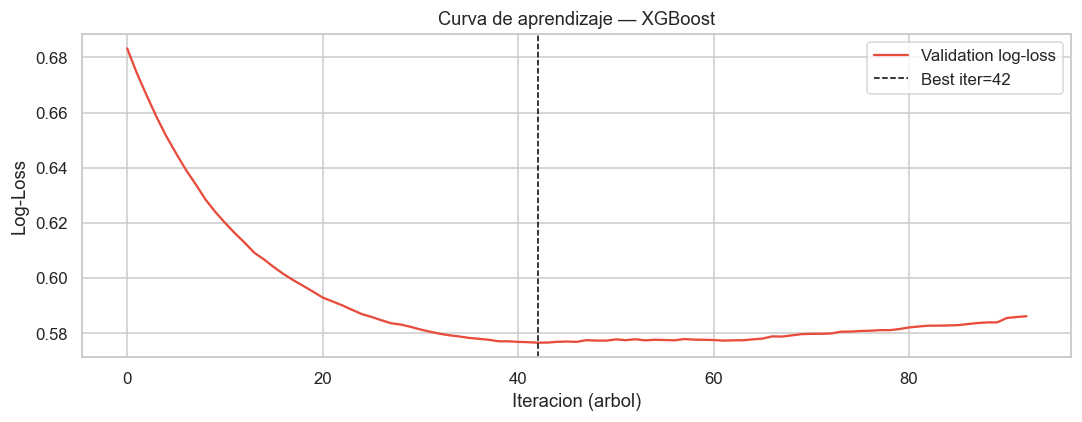

In [16]:
# ============================================================
# 7. ENTRENAMIENTO — XGBoost
# ============================================================

n_neg    = int((y_train == 0).sum())
n_pos    = int((y_train == 1).sum())
scale_pw = n_neg / n_pos if n_pos > 0 else 1.0
print(f"scale_pos_weight = {scale_pw:.3f}  (neg={n_neg}, pos={n_pos})")

model = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=scale_pw)

print("\nEntrenando XGBoost...")
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

best_iter = model.best_iteration
print(f"\nEntrenamiento completado. Mejor iteracion: {best_iter}")

# Curva de aprendizaje
results   = model.evals_result()
train_log = results["validation_0"]["logloss"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_log, lw=1.5, color="#e74c3c", label="Validation log-loss")
ax.axvline(best_iter, color="black", linestyle="--", lw=1, label=f"Best iter={best_iter}")
ax.set_xlabel("Iteracion (arbol)")
ax.set_ylabel("Log-Loss")
ax.set_title("Curva de aprendizaje — XGBoost")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Evaluación del Modelo

Métricas reportadas sobre **validación** y **test**:
- Accuracy, ROC-AUC, Brier Score.
- Classification report (precision / recall / F1 por clase).

Visualizaciones:
- Curva ROC.
- Curva de calibración.
- Distribución de P(UP) por clase.
- Matriz de confusión.


  VALIDACION
  Accuracy : 0.6843
  ROC-AUC  : 0.7594
  Brier    : 0.1980  (0=perfecto, 0.25=random)

              precision    recall  f1-score   support

        DOWN       0.68      0.66      0.67      5057
          UP       0.69      0.70      0.70      5422

    accuracy                           0.68     10479
   macro avg       0.68      0.68      0.68     10479
weighted avg       0.68      0.68      0.68     10479


  TEST
  Accuracy : 0.7095
  ROC-AUC  : 0.7838
  Brier    : 0.1899  (0=perfecto, 0.25=random)

              precision    recall  f1-score   support

        DOWN       0.75      0.69      0.72      5572
          UP       0.67      0.73      0.70      4810

    accuracy                           0.71     10382
   macro avg       0.71      0.71      0.71     10382
weighted avg       0.71      0.71      0.71     10382



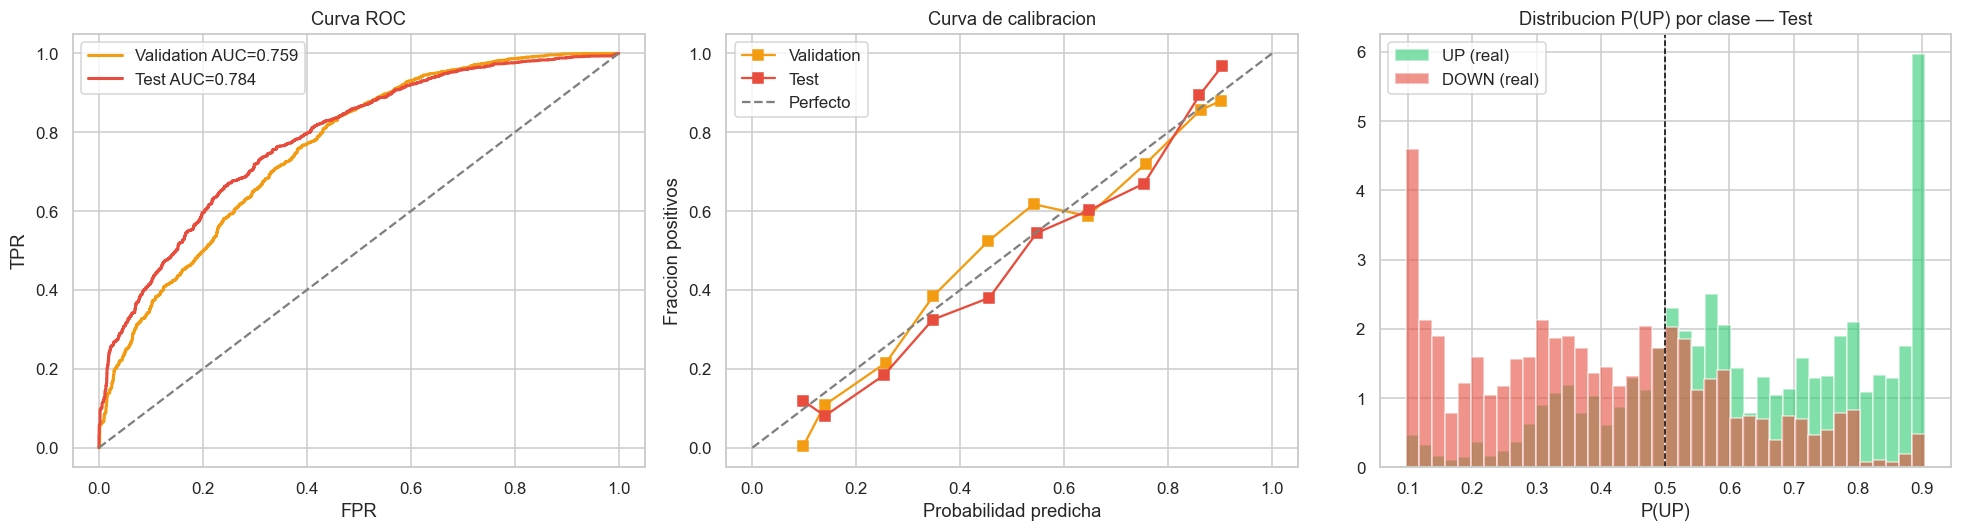

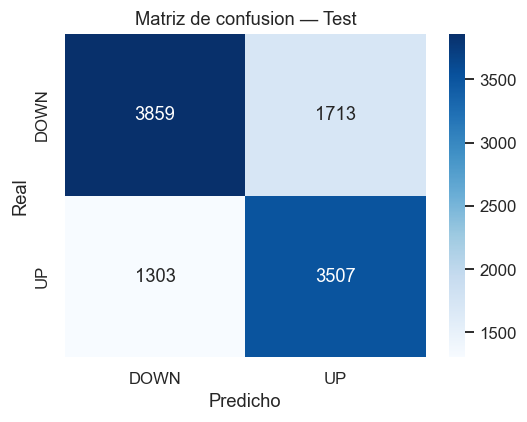

In [17]:
# ============================================================
# 8. EVALUACIÓN DEL MODELO
# ============================================================

def evaluate_split(name, X, y, trained_model):
    proba  = trained_model.predict_proba(X)[:, 1]
    pred   = (proba >= 0.5).astype(int)
    acc    = accuracy_score(y, pred)
    auc    = roc_auc_score(y, proba)
    brier  = brier_score_loss(y, proba)
    report = classification_report(y, pred, target_names=["DOWN", "UP"])
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Brier    : {brier:.4f}  (0=perfecto, 0.25=random)")
    print(f"\n{report}")
    return proba, pred, acc, auc, brier

prob_val,  pred_val,  acc_val,  auc_val,  brier_val  = evaluate_split("VALIDACION", X_val,  y_val,  model)
prob_test, pred_test, acc_test, auc_test, brier_test = evaluate_split("TEST",       X_test, y_test, model)

# Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC
for proba, y_true, name, color in [
    (prob_val,  y_val,  "Validation", "#f39c12"),
    (prob_test, y_test, "Test",       "#e74c3c"),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc_s = roc_auc_score(y_true, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} AUC={auc_s:.3f}", color=color)
axes[0].plot([0,1],[0,1],"--", color="gray")
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend()

# Calibracion
for proba, y_true, name, color in [
    (prob_val,  y_val,  "Validation", "#f39c12"),
    (prob_test, y_test, "Test",       "#e74c3c"),
]:
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10)
    axes[1].plot(mean_pred, frac_pos, "s-", label=name, color=color)
axes[1].plot([0,1],[0,1],"--", color="gray", label="Perfecto")
axes[1].set_title("Curva de calibracion")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Fraccion positivos")
axes[1].legend()

# Distribucion P(UP) por clase
axes[2].hist(prob_test[y_test == 1], bins=40, alpha=0.6, color="#2ecc71", label="UP (real)",   density=True)
axes[2].hist(prob_test[y_test == 0], bins=40, alpha=0.6, color="#e74c3c", label="DOWN (real)", density=True)
axes[2].axvline(0.5, color="black", lw=1, linestyle="--")
axes[2].set_title("Distribucion P(UP) por clase — Test")
axes[2].set_xlabel("P(UP)")
axes[2].legend()

plt.tight_layout()
plt.show()

# Matriz de confusion
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["DOWN","UP"], yticklabels=["DOWN","UP"], ax=ax)
ax.set_ylabel("Real"); ax.set_xlabel("Predicho")
ax.set_title("Matriz de confusion — Test")
plt.tight_layout()
plt.show()


## 9. Probabilidades y Expected Value (EV)

Para cada snapshot calculamos el **EV neto** de cada posición:

```
EV_UP   = P(UP)   × up_win_net   + P(DOWN) × up_loss_net
EV_DOWN = P(DOWN) × down_win_net + P(UP)   × down_loss_net
```

`up_win_net` y `up_loss_net` ya incluyen las fees. `up_loss_net` es siempre negativo.

---

## 10. Generación de Señales

Lógica de decisión (sin look-ahead):

| Condición | Señal |
|-----------|-------|
| `EV_UP > threshold` y `EV_UP ≥ EV_DOWN` | `LONG_UP` |
| `EV_DOWN > threshold` y `EV_DOWN > EV_UP` | `LONG_DOWN` |
| Ninguno supera el umbral | `NO_TRADE` |

Se ejecuta **una sola operación por mercado**: la primera señal válida (snapshot con más tiempo restante que ya supera el umbral).

---

## 11. Backtest de Equity

Simulación de cartera con stake fijo y capital inicial configurables.  
No se mira el futuro: la señal se genera con datos del snapshot en ese momento.  
La operación se cierra al término del mercado.

Incluye:
- Tabla de trades.
- Equity curve + drawdown.
- Estadísticas resumidas (win rate, profit factor, ROI, max drawdown).
- Análisis de sensibilidad del umbral EV.

---

## 12. Interpretabilidad

- Feature importance por ganancia (XGBoost built-in).
- Categorización de features por tipo.
- SHAP Summary Plot (si `shap` está instalado).

---

## 13. Tabla Resumen Final y Conclusiones

Resumen completo de métricas del modelo y del backtest, más sugerencias de mejora para producción.

Estadisticas de EV (test):
           ev_up    ev_down  roi_up_exp  roi_down_exp
count 10382.0000 10382.0000  10382.0000    10382.0000
mean      2.1495     1.5219      0.2149        0.1522
std      10.7325    11.5658      1.0733        1.1566
min      -4.7424    -7.3844     -0.4742       -0.7384
25%      -0.7777    -0.8628     -0.0778       -0.0863
50%      -0.0753    -0.2791     -0.0075       -0.0279
75%       0.8537     0.8637      0.0854        0.0864
max     173.2706   319.5298     17.3271       31.9530

Cobertura en test (EV > 0.05 USDC):
  EV_UP   > threshold: 45.5% de snapshots
  EV_DOWN > threshold: 37.8% de snapshots


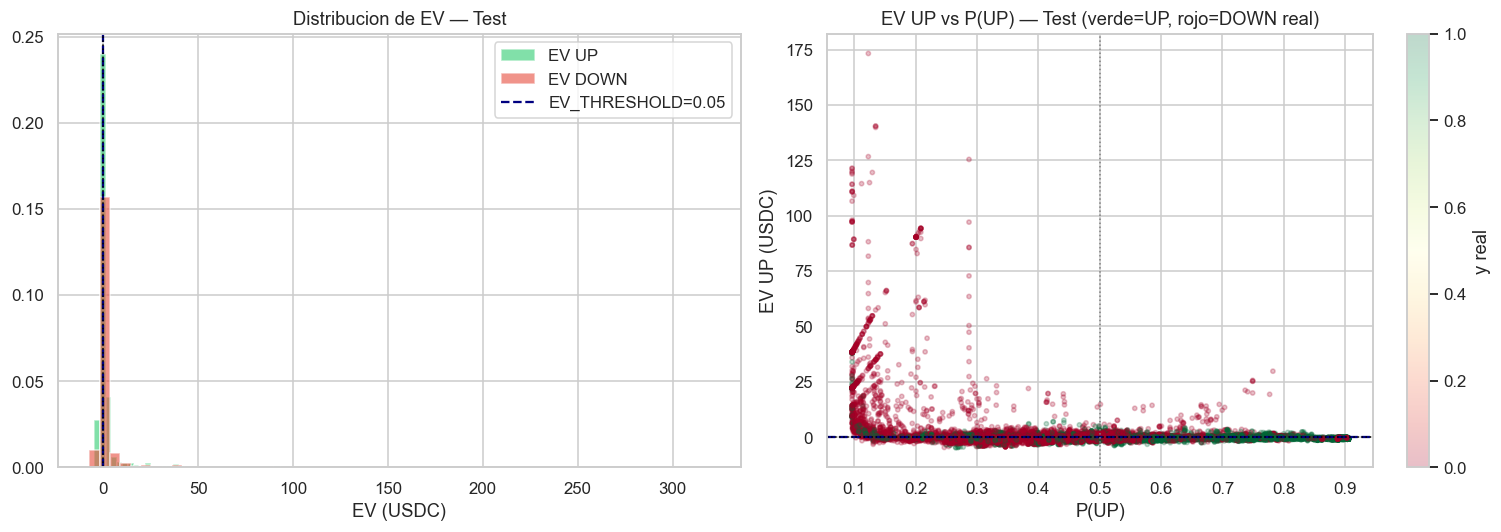

Distribucion de señales en test (snapshots):
signal
LONG_UP      4725
LONG_DOWN    3925
NO_TRADE     1732
Name: count, dtype: int64

  Cobertura activa: 83.3% de snapshots

Trades en test: 117 de 117 mercados
  LONG_UP:   65
  LONG_DOWN: 52
  Sin señal: 0


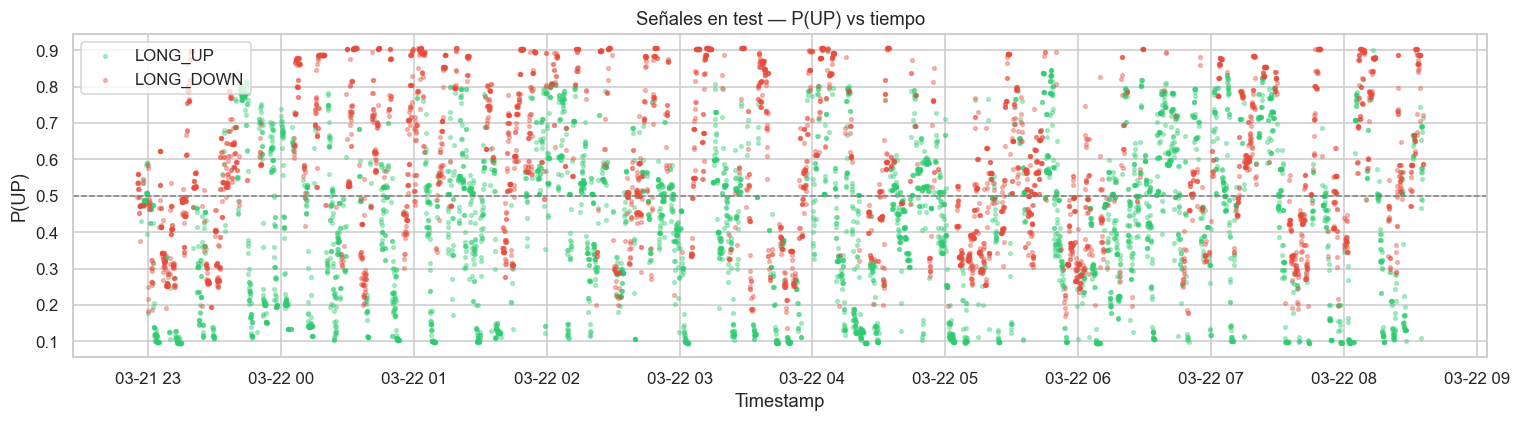


  BACKTEST — TEST
  Trades totales     : 117
  Win rate           : 49.57%
  Profit Factor      : 1.024
  PnL total          : +13.90 USDC
  ROI total          : +1.39%
  Avg PnL / trade    : +0.1188 USDC
  Avg win            : +10.4222 USDC
  Avg loss           : -10.0100 USDC
  Max drawdown       : -13.40%
  Capital inicial    : 1000.00 USDC
  Capital final      : 1013.90 USDC

  BACKTEST — FULL (train+val+test)
  Trades totales     : 773
  Win rate           : 58.60%
  Profit Factor      : 1.430
  PnL total          : +1378.37 USDC
  ROI total          : +137.84%
  Avg PnL / trade    : +1.7831 USDC
  Avg win            : +10.1139 USDC
  Avg loss           : -10.0100 USDC
  Max drawdown       : -5.85%
  Capital inicial    : 1000.00 USDC
  Capital final      : 2378.37 USDC

Primeras filas de la tabla de trades (test):
                       timestamp    signal resolution   win      pnl  ev_expected   p_up   capital
2026-03-21 22:55:04.999130+00:00 LONG_DOWN       down  True  10.1700 

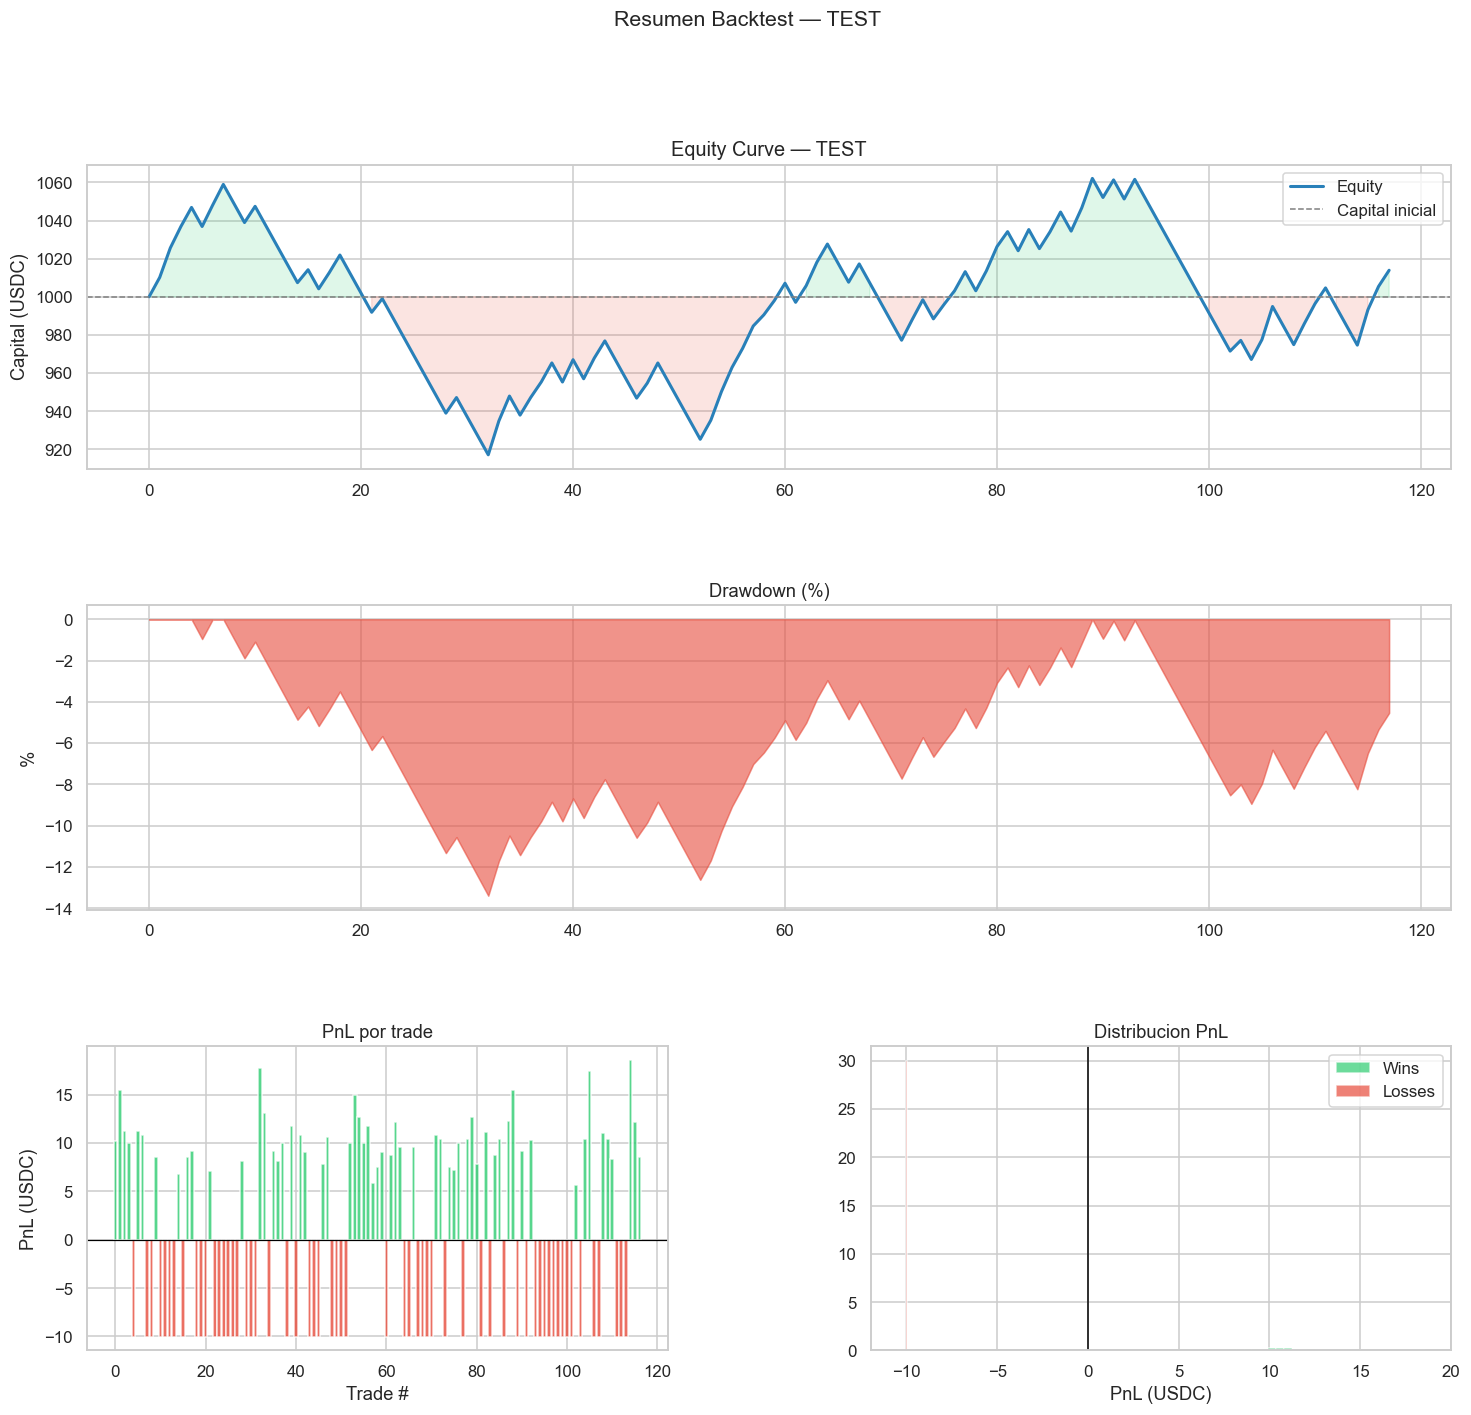

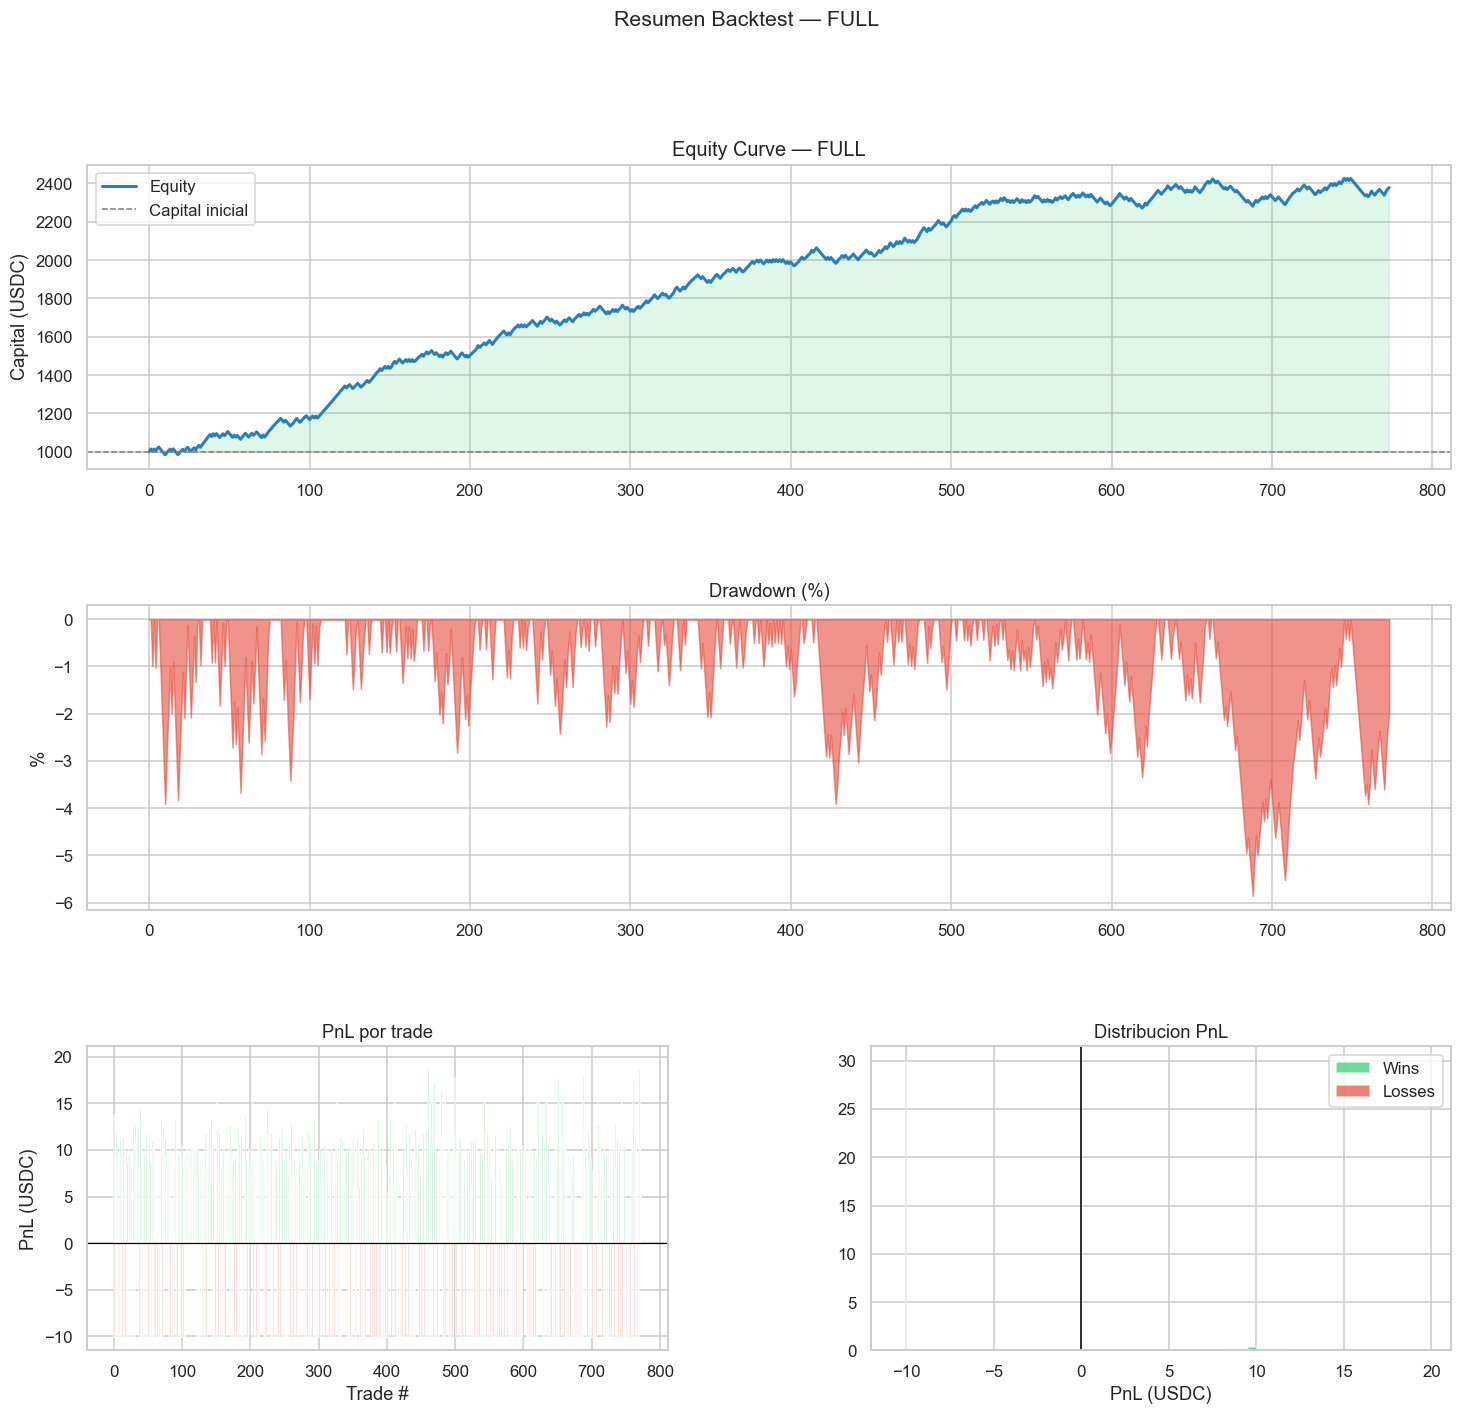


Sensibilidad del umbral EV — test
 Threshold |  Trades |   Win% |     PF |     ROI% |   MaxDD%
-----------------------------------------------------------------
      0.00 |     117 |  50.4% |   1.04 |   +2.46% |  -11.56%
      0.02 |     117 |  49.6% |   1.02 |   +1.34% |  -13.39%
      0.05 |     117 |  49.6% |   1.02 |   +1.39% |  -13.40%
      0.08 |     117 |  50.4% |   1.05 |   +3.17% |  -11.30%
      0.10 |     117 |  50.4% |   1.06 |   +3.27% |  -11.30%
      0.15 |     117 |  49.6% |   1.05 |   +2.80% |  -14.52%
      0.20 |     117 |  50.4% |   1.09 |   +4.95% |  -14.47%
      0.30 |     117 |  51.3% |   1.13 |   +7.60% |  -12.38%


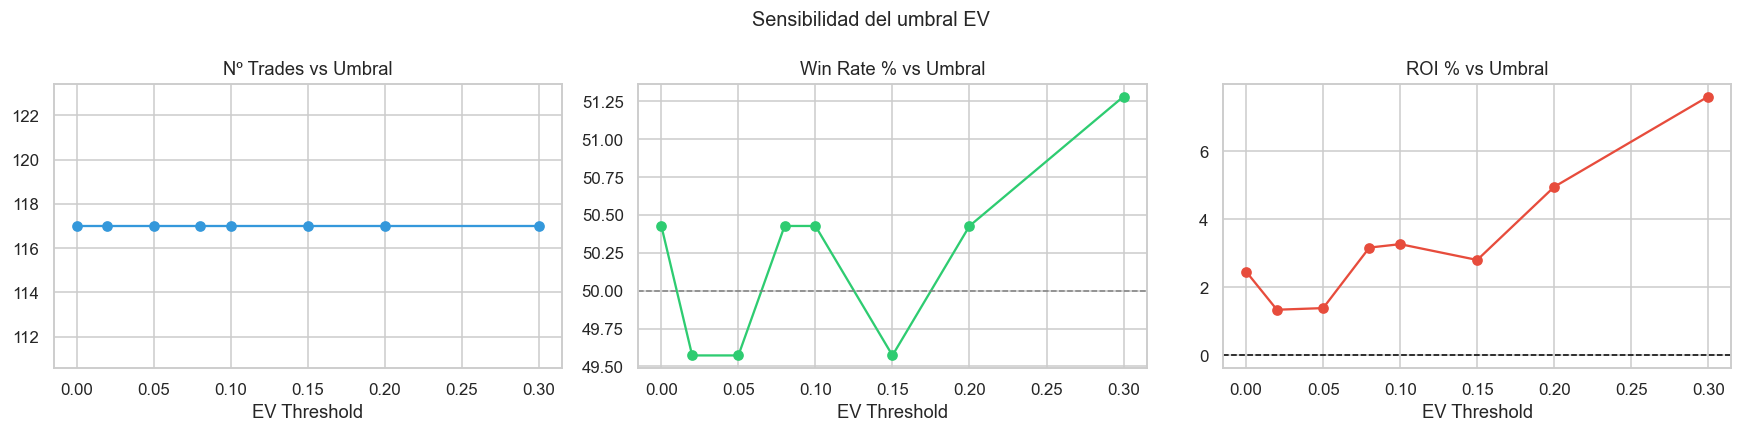

Top 20 features (gain):
        feature  importance
   down_bid_p_3      0.1443
 down_mid_price      0.0990
   up_mid_price      0.0741
   down_win_net      0.0735
down_break_even      0.0684
   down_ask_p_1      0.0600
   down_bid_p_2      0.0504
     up_bid_p_3      0.0452
dn_roi_estimate      0.0375
     up_bid_p_2      0.0331
     up_ask_p_1      0.0261
   down_bid_p_1      0.0247
     up_win_net      0.0218
     up_bid_p_1      0.0210
  up_break_even      0.0199
   down_ask_p_3      0.0105
     ret_x_prog      0.0102
dn_edge_over_be      0.0095
up_roi_estimate      0.0085
    ema_6_vs_12      0.0075


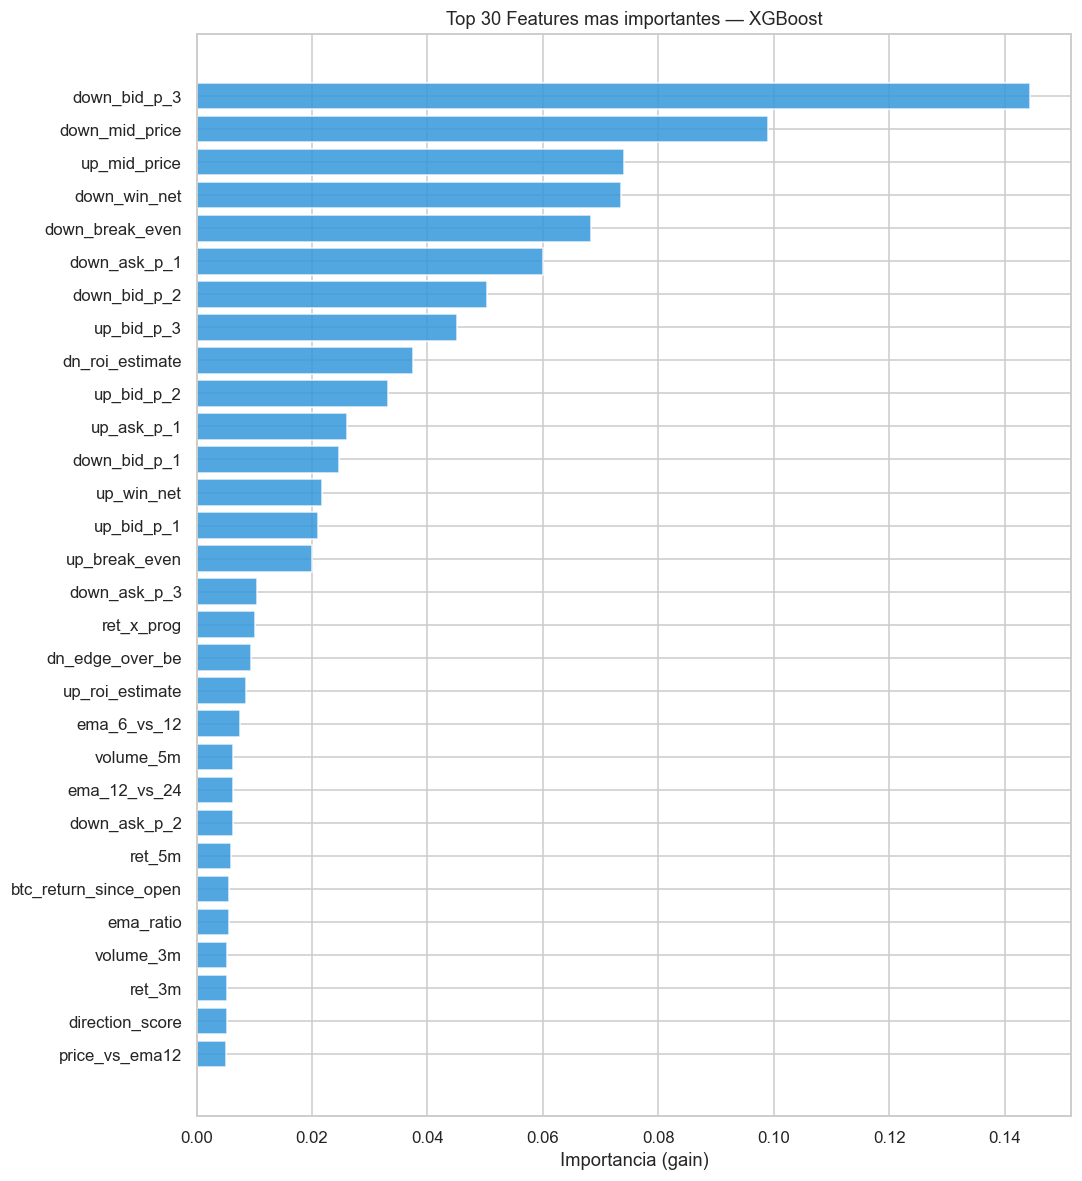

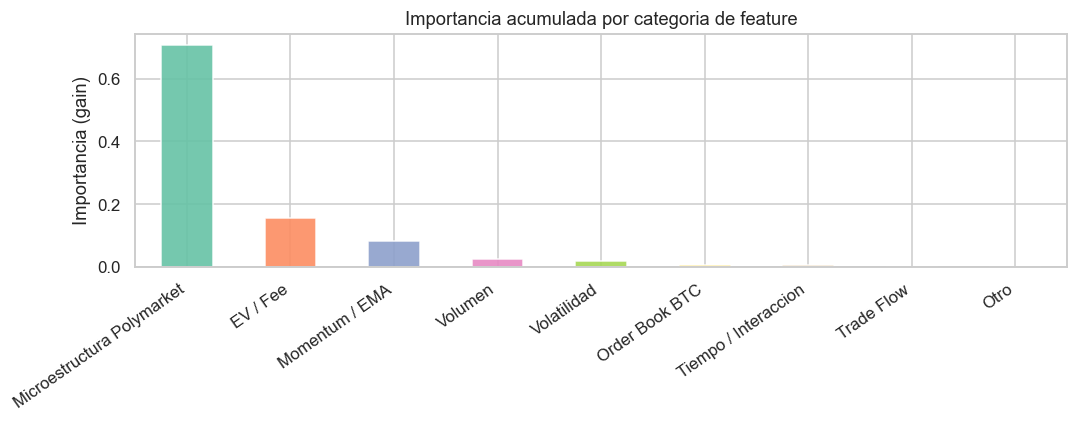

shap no instalado. Instala con: pip install shap

  RESUMEN FINAL DEL SISTEMA

Modelo: XGBoost
  Features usadas    : 74
  Mejor iteracion    : 42
  ROC-AUC (val)      : 0.7594
  ROC-AUC (test)     : 0.7838
  Accuracy (test)    : 0.7095
  Brier Score (test) : 0.1899

Backtest TEST:
  n_trades              : 117
  win_rate              : +0.4957
  profit_factor         : +1.0235
  total_pnl             : +13.8973
  roi_total             : +1.3897
  max_drawdown          : -13.3967
  equity_final          : +1013.8973

Backtest FULL:
  n_trades              : 773
  win_rate              : +0.5860
  profit_factor         : +1.4303
  total_pnl             : +1378.3748
  roi_total             : +137.8375
  max_drawdown          : -5.8539
  equity_final          : +2378.3748

  PROXIMOS PASOS SUGERIDOS
  1. Calibracion de probabilidades (CalibratedClassifierCV) si Brier Score es alto
  2. Stake variable con Kelly Criterion: f = (p*b - (1-p)) / b
  3. Feature selection con SHAP-based pruning


In [18]:
# ============================================================
# 9. PROBABILIDADES Y EXPECTED VALUE (EV)
# ============================================================
#
# EV_UP   = P(UP)   * up_win_net   + P(DOWN) * up_loss_net
# EV_DOWN = P(DOWN) * down_win_net + P(UP)   * down_loss_net
#
# up_win_net y up_loss_net ya llevan las fees incorporadas.
# up_loss_net y down_loss_net son negativos por definicion.

def compute_ev(df_split, X_split, trained_model):
    # Calcula probabilidades calibradas y EV neto por snapshot.
    out = df_split.copy()
    out["p_up"]   = trained_model.predict_proba(X_split)[:, 1]
    out["p_down"] = 1.0 - out["p_up"]

    out["ev_up"]   = out["p_up"]   * out["up_win_net"]   + out["p_down"] * out["up_loss_net"]
    out["ev_down"] = out["p_down"] * out["down_win_net"] + out["p_up"]   * out["down_loss_net"]

    out["roi_up_exp"]   = out["ev_up"]   / STAKE
    out["roi_down_exp"] = out["ev_down"] / STAKE
    return out

df_train_ev = compute_ev(df_train, X_train, model)
df_val_ev   = compute_ev(df_val,   X_val,   model)
df_test_ev  = compute_ev(df_test,  X_test,  model)

print("Estadisticas de EV (test):")
print(df_test_ev[["ev_up","ev_down","roi_up_exp","roi_down_exp"]].describe().round(4))

pct_up   = (df_test_ev["ev_up"]   > EV_THRESHOLD).mean() * 100
pct_down = (df_test_ev["ev_down"] > EV_THRESHOLD).mean() * 100
print(f"\nCobertura en test (EV > {EV_THRESHOLD} USDC):")
print(f"  EV_UP   > threshold: {pct_up:.1f}% de snapshots")
print(f"  EV_DOWN > threshold: {pct_down:.1f}% de snapshots")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ev_col, label, color in [
    ("ev_up",   "EV UP",   "#2ecc71"),
    ("ev_down", "EV DOWN", "#e74c3c"),
]:
    axes[0].hist(df_test_ev[ev_col], bins=60, alpha=0.6, label=label, color=color, density=True)
axes[0].axvline(EV_THRESHOLD, color="navy", lw=1.5, linestyle="--",
                label=f"EV_THRESHOLD={EV_THRESHOLD}")
axes[0].axvline(0, color="black", lw=1, linestyle=":")
axes[0].set_title("Distribucion de EV — Test")
axes[0].set_xlabel("EV (USDC)")
axes[0].legend()

sc = axes[1].scatter(df_test_ev["p_up"], df_test_ev["ev_up"],
                     c=df_test_ev["y"], cmap="RdYlGn", alpha=0.25, s=8)
axes[1].axhline(EV_THRESHOLD, color="navy", lw=1.5, linestyle="--")
axes[1].axhline(0, color="black", lw=1, linestyle=":")
axes[1].axvline(0.5, color="gray", lw=1, linestyle=":")
axes[1].set_xlabel("P(UP)")
axes[1].set_ylabel("EV UP (USDC)")
axes[1].set_title("EV UP vs P(UP) — Test (verde=UP, rojo=DOWN real)")
plt.colorbar(sc, ax=axes[1], label="y real")
plt.tight_layout()
plt.show()


# ============================================================
# 10. GENERACIÓN DE SEÑALES DE TRADING
# ============================================================
#
# Logica de decision:
#   EV_UP  > threshold Y EV_UP  >= EV_DOWN  ->  LONG_UP
#   EV_DOWN> threshold Y EV_DOWN > EV_UP    ->  LONG_DOWN
#   Ninguno supera el umbral                 ->  NO_TRADE
#
# Una operacion por mercado: primera señal valida (snapshot con
# mas tiempo restante que ya supera el umbral).

def assign_signal(ev_up, ev_down, threshold=EV_THRESHOLD):
    long_up   = ev_up   > threshold
    long_down = ev_down > threshold
    if long_up and long_down:
        return "LONG_UP" if ev_up >= ev_down else "LONG_DOWN"
    if long_up:   return "LONG_UP"
    if long_down: return "LONG_DOWN"
    return "NO_TRADE"

def add_signals(df_ev):
    out = df_ev.copy()
    out["signal"] = out.apply(
        lambda r: assign_signal(r["ev_up"], r["ev_down"]), axis=1
    )
    return out

df_train_sig = add_signals(df_train_ev)
df_val_sig   = add_signals(df_val_ev)
df_test_sig  = add_signals(df_test_ev)

# Dataset completo para backtest full
df_all_sig = pd.concat([df_train_sig, df_val_sig, df_test_sig]).sort_values(
    ["timestamp", "market_slug", "seconds_left"],
    ascending=[True, True, False]
).reset_index(drop=True)

test_signal_dist = df_test_sig["signal"].value_counts()
print("Distribucion de señales en test (snapshots):")
print(test_signal_dist)
print(f"\n  Cobertura activa: {(df_test_sig['signal']!='NO_TRADE').mean()*100:.1f}% de snapshots")

def first_valid_signal(df_signals):
    # Selecciona la primera señal valida (no NO_TRADE) por mercado,
    # ordenando por seconds_left descendente (mas tiempo = antes en el mercado).
    df_sorted = df_signals.sort_values(
        ["market_slug", "seconds_left"], ascending=[True, False]
    )
    df_valid  = df_sorted[df_sorted["signal"] != "NO_TRADE"]
    return df_valid.groupby("market_slug").first().reset_index()

trades_test = first_valid_signal(df_test_sig)
print(f"\nTrades en test: {len(trades_test)} de {df_test_sig['market_slug'].nunique()} mercados")
print(f"  LONG_UP:   {(trades_test['signal']=='LONG_UP').sum()}")
print(f"  LONG_DOWN: {(trades_test['signal']=='LONG_DOWN').sum()}")
print(f"  Sin señal: {df_test_sig['market_slug'].nunique() - len(trades_test)}")

# Visualizacion de señales en el tiempo
fig, ax = plt.subplots(figsize=(14, 4))
for sig, color in [("LONG_UP","#2ecc71"), ("LONG_DOWN","#e74c3c")]:
    sub = df_test_sig[df_test_sig["signal"] == sig]
    ax.scatter(sub["timestamp"], sub["p_up"], c=color, alpha=0.35, s=6, label=sig)
ax.axhline(0.5, color="gray", lw=1, linestyle="--")
ax.set_title("Señales en test — P(UP) vs tiempo")
ax.set_xlabel("Timestamp"); ax.set_ylabel("P(UP)")
ax.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11. BACKTEST DE EQUITY
# ============================================================

def run_backtest(df_signals, initial_capital=INITIAL_CAPITAL, stake=STAKE,
                 ev_threshold=EV_THRESHOLD):
    # Ejecuta backtest. Una operacion por mercado (primera señal valida).
    # No mira el futuro: señal generada con datos del snapshot en ese momento.
    first_sigs = first_valid_signal(df_signals)
    if len(first_sigs) == 0:
        return pd.DataFrame(), [initial_capital]

    capital = initial_capital
    equity  = [capital]
    records = []

    for _, trade in first_sigs.sort_values("timestamp").iterrows():
        signal     = trade["signal"]
        resolution = trade["resolution"]

        if signal == "LONG_UP":
            win_cond  = (resolution == "up")
            pnl       = trade["up_win_net"] if win_cond else trade["up_loss_net"]
            ev_used   = trade["ev_up"]
            roi_exp   = trade["roi_up_exp"]
            entry_px  = trade["up_avg_fill"]
        elif signal == "LONG_DOWN":
            win_cond  = (resolution == "down")
            pnl       = trade["down_win_net"] if win_cond else trade["down_loss_net"]
            ev_used   = trade["ev_down"]
            roi_exp   = trade["roi_down_exp"]
            entry_px  = trade["down_avg_fill"]
        else:
            continue

        capital += pnl
        equity.append(capital)
        records.append({
            "timestamp":    trade["timestamp"],
            "market_slug":  trade["market_slug"],
            "signal":       signal,
            "resolution":   resolution,
            "win":          bool(win_cond),
            "pnl":          float(pnl),
            "ev_expected":  float(ev_used),
            "roi_expected": float(roi_exp),
            "entry_price":  float(entry_px),
            "seconds_left": float(trade["seconds_left"]),
            "p_up":         float(trade["p_up"]),
            "capital":      float(capital),
        })

    return pd.DataFrame(records), equity


def compute_stats(trade_df, equity_curve, initial_capital=INITIAL_CAPITAL, label=""):
    if len(trade_df) == 0:
        print(f"  Sin trades en '{label}'")
        return {}

    wins  = trade_df["win"]
    pnls  = trade_df["pnl"]

    win_rate     = wins.mean()
    total_pnl    = pnls.sum()
    roi_total    = total_pnl / initial_capital * 100
    avg_pnl      = pnls.mean()
    avg_win      = pnls[wins].mean()  if wins.sum() > 0  else 0.0
    avg_loss     = pnls[~wins].mean() if (~wins).sum() > 0 else 0.0
    gross_profit = pnls[wins].sum()   if wins.sum() > 0  else 0.0
    gross_loss   = abs(pnls[~wins].sum()) if (~wins).sum() > 0 else 1e-9
    profit_fac   = gross_profit / gross_loss

    eq_s    = pd.Series(equity_curve)
    mdd_pct = ((eq_s - eq_s.cummax()) / eq_s.cummax() * 100).min()

    print(f"\n{'='*55}")
    print(f"  BACKTEST — {label}")
    print(f"{'='*55}")
    print(f"  Trades totales     : {len(trade_df)}")
    print(f"  Win rate           : {win_rate*100:.2f}%")
    print(f"  Profit Factor      : {profit_fac:.3f}")
    print(f"  PnL total          : {total_pnl:+.2f} USDC")
    print(f"  ROI total          : {roi_total:+.2f}%")
    print(f"  Avg PnL / trade    : {avg_pnl:+.4f} USDC")
    print(f"  Avg win            : {avg_win:+.4f} USDC")
    print(f"  Avg loss           : {avg_loss:+.4f} USDC")
    print(f"  Max drawdown       : {mdd_pct:.2f}%")
    print(f"  Capital inicial    : {initial_capital:.2f} USDC")
    print(f"  Capital final      : {equity_curve[-1]:.2f} USDC")

    return dict(
        n_trades=len(trade_df), win_rate=win_rate,
        profit_factor=profit_fac, total_pnl=total_pnl,
        roi_total=roi_total, max_drawdown=mdd_pct,
        equity_final=equity_curve[-1],
    )


# Backtest TEST
trd_test, eq_test = run_backtest(df_test_sig)
stats_test = compute_stats(trd_test, eq_test, label="TEST")

# Backtest FULL
trd_all, eq_all = run_backtest(df_all_sig)
stats_all = compute_stats(trd_all, eq_all, label="FULL (train+val+test)")

if len(trd_test):
    print("\nPrimeras filas de la tabla de trades (test):")
    print(trd_test[["timestamp","signal","resolution","win","pnl",
                     "ev_expected","p_up","capital"]].head(8).to_string(index=False))


def plot_backtest(trade_df, equity_curve, title="Backtest", initial_capital=INITIAL_CAPITAL):
    if len(trade_df) == 0:
        print("Sin trades para visualizar")
        return

    eq_s       = pd.Series(equity_curve)
    rolling_mx = eq_s.cummax()
    dd_series  = (eq_s - rolling_mx) / rolling_mx * 100

    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Equity curve
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(eq_s.values, lw=2, color="#2980b9", label="Equity")
    ax1.axhline(initial_capital, color="gray", linestyle="--", lw=1, label="Capital inicial")
    ax1.fill_between(range(len(eq_s)), eq_s, initial_capital,
                     where=(eq_s >= initial_capital), alpha=0.15, color="#2ecc71")
    ax1.fill_between(range(len(eq_s)), eq_s, initial_capital,
                     where=(eq_s < initial_capital), alpha=0.15, color="#e74c3c")
    ax1.set_title(f"Equity Curve — {title}", fontsize=13)
    ax1.set_ylabel("Capital (USDC)")
    ax1.legend()

    # Drawdown
    ax2 = fig.add_subplot(gs[1, :])
    ax2.fill_between(range(len(dd_series)), dd_series, 0, alpha=0.6, color="#e74c3c")
    ax2.set_title("Drawdown (%)")
    ax2.set_ylabel("%")

    # PnL por trade
    ax3 = fig.add_subplot(gs[2, 0])
    colors = ["#2ecc71" if w else "#e74c3c" for w in trade_df["win"]]
    ax3.bar(range(len(trade_df)), trade_df["pnl"], color=colors, alpha=0.8)
    ax3.axhline(0, color="black", lw=0.8)
    ax3.set_title("PnL por trade")
    ax3.set_xlabel("Trade #"); ax3.set_ylabel("PnL (USDC)")

    # Distribucion PnL
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.hist(trade_df[trade_df["win"]]["pnl"],  bins=30, color="#2ecc71", alpha=0.7,
             label="Wins",   density=True)
    ax4.hist(trade_df[~trade_df["win"]]["pnl"], bins=30, color="#e74c3c", alpha=0.7,
             label="Losses", density=True)
    ax4.axvline(0, color="black", lw=1)
    ax4.set_title("Distribucion PnL")
    ax4.set_xlabel("PnL (USDC)")
    ax4.legend()

    plt.suptitle(f"Resumen Backtest — {title}", fontsize=14)
    plt.show()


plot_backtest(trd_test, eq_test, title="TEST")
plot_backtest(trd_all,  eq_all,  title="FULL")


# Analisis de sensibilidad del umbral EV
print("\nSensibilidad del umbral EV — test")
print("=" * 65)
print(f"{'Threshold':>10} | {'Trades':>7} | {'Win%':>6} | {'PF':>6} | {'ROI%':>8} | {'MaxDD%':>8}")
print("-" * 65)

sens_rows = []
for thresh in [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]:
    df_tmp = df_test_ev.copy()
    df_tmp["signal"] = df_tmp.apply(
        lambda r: assign_signal(r["ev_up"], r["ev_down"], threshold=thresh), axis=1
    )
    df_tmp["roi_up_exp"]   = df_tmp["ev_up"]   / STAKE
    df_tmp["roi_down_exp"] = df_tmp["ev_down"] / STAKE

    trd_t, eq_t = run_backtest(df_tmp)

    if len(trd_t) == 0:
        print(f"{thresh:>10.2f} | {'0':>7} | {'—':>6} | {'—':>6} | {'—':>8} | {'—':>8}")
        sens_rows.append({"threshold": thresh, "trades": 0})
        continue

    wr  = trd_t["win"].mean() * 100
    gp  = trd_t[trd_t["win"]]["pnl"].sum()
    gl  = abs(trd_t[~trd_t["win"]]["pnl"].sum()) + 1e-9
    pf  = gp / gl
    roi = (eq_t[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    es  = pd.Series(eq_t)
    mdd = ((es - es.cummax()) / es.cummax() * 100).min()

    print(f"{thresh:>10.2f} | {len(trd_t):>7} | {wr:>5.1f}% | {pf:>6.2f} | {roi:>+7.2f}% | {mdd:>+7.2f}%")
    sens_rows.append({"threshold": thresh, "trades": len(trd_t),
                      "win_rate": wr, "profit_factor": pf, "roi": roi, "max_dd": mdd})

sens_df = pd.DataFrame(sens_rows).dropna()
if len(sens_df) > 2:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(sens_df["threshold"], sens_df["trades"],       "o-", color="#3498db")
    axes[0].set_title("Nº Trades vs Umbral"); axes[0].set_xlabel("EV Threshold")

    axes[1].plot(sens_df["threshold"], sens_df["win_rate"],     "o-", color="#2ecc71")
    axes[1].axhline(50, color="gray", linestyle="--", lw=1)
    axes[1].set_title("Win Rate % vs Umbral"); axes[1].set_xlabel("EV Threshold")

    axes[2].plot(sens_df["threshold"], sens_df["roi"],          "o-", color="#e74c3c")
    axes[2].axhline(0,  color="black", linestyle="--", lw=1)
    axes[2].set_title("ROI % vs Umbral"); axes[2].set_xlabel("EV Threshold")

    plt.suptitle("Sensibilidad del umbral EV", fontsize=13)
    plt.tight_layout()
    plt.show()


# ============================================================
# 12. INTERPRETABILIDAD
# ============================================================

importance = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Top 20 features (gain):")
print(importance.head(20).to_string(index=False))

top_n   = min(30, len(importance))
top_imp = importance.head(top_n)
fig, ax = plt.subplots(figsize=(10, top_n * 0.33 + 1))
ax.barh(top_imp["feature"][::-1], top_imp["importance"][::-1],
        color="#3498db", alpha=0.85)
ax.set_xlabel("Importancia (gain)")
ax.set_title(f"Top {top_n} Features mas importantes — XGBoost")
plt.tight_layout()
plt.show()

def categorize_feature(name):
    if any(k in name for k in ["ret_","btc_ret","btc_accel","direction_score",
                                "ema_3_vs","ema_6_vs","ema_12_vs","ema_trend",
                                "ema_ratio","price_vs_ema"]):
        return "Momentum / EMA"
    if any(k in name for k in ["up_ask","up_bid","down_ask","down_bid",
                                "up_spread","down_spread","up_mid","down_mid",
                                "up_depth","down_depth","up_liq","down_liq",
                                "up_break","down_break","market_vig","implied","up_dn"]):
        return "Microestructura Polymarket"
    if any(k in name for k in ["ev_","roi_","up_win","up_loss","down_win","down_loss",
                                "up_edge","dn_edge","up_roi","dn_roi"]):
        return "EV / Fee"
    if any(k in name for k in ["orderbook_imb","bid_vol","ask_vol","spread","ob_"]):
        return "Order Book BTC"
    if any(k in name for k in ["trade_imb","buy_vol","sell_vol","flow"]):
        return "Trade Flow"
    if any(k in name for k in ["volume_","vol_"]):
        return "Volumen"
    if any(k in name for k in ["volatility_","vola_"]):
        return "Volatilidad"
    if any(k in name for k in ["seconds_left","market_progress","time_pressure",
                                "_x_","_x_time","_x_prog"]):
        return "Tiempo / Interaccion"
    return "Otro"

importance["category"] = importance["feature"].apply(categorize_feature)
cat_imp = importance.groupby("category")["importance"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
cat_imp.plot(kind="bar", ax=ax, color=sns.color_palette("Set2", n_colors=len(cat_imp)), alpha=0.9)
ax.set_title("Importancia acumulada por categoria de feature")
ax.set_ylabel("Importancia (gain)")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# SHAP (opcional)
try:
    import shap
    print("\nCalculando SHAP values (puede tardar unos segundos)...")
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test.iloc[:500])
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_test.iloc[:500], feature_names=FEATURE_COLS,
                      max_display=20, show=False)
    plt.title("SHAP Summary Plot (test, 500 muestras)")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("shap no instalado. Instala con: pip install shap")


# ============================================================
# 13. TABLA RESUMEN FINAL Y CONCLUSIONES
# ============================================================

print("\n" + "=" * 55)
print("  RESUMEN FINAL DEL SISTEMA")
print("=" * 55)
print(f"\nModelo: XGBoost")
print(f"  Features usadas    : {len(FEATURE_COLS)}")
print(f"  Mejor iteracion    : {model.best_iteration}")
print(f"  ROC-AUC (val)      : {auc_val:.4f}")
print(f"  ROC-AUC (test)     : {auc_test:.4f}")
print(f"  Accuracy (test)    : {acc_test:.4f}")
print(f"  Brier Score (test) : {brier_test:.4f}")

if stats_test:
    print(f"\nBacktest TEST:")
    for k, v in stats_test.items():
        if isinstance(v, float):
            print(f"  {k:<22}: {v:+.4f}")
        else:
            print(f"  {k:<22}: {v}")

if stats_all:
    print(f"\nBacktest FULL:")
    for k, v in stats_all.items():
        if isinstance(v, float):
            print(f"  {k:<22}: {v:+.4f}")
        else:
            print(f"  {k:<22}: {v}")

print("\n" + "=" * 55)
print("  PROXIMOS PASOS SUGERIDOS")
print("=" * 55)
suggestions = [
    "Calibracion de probabilidades (CalibratedClassifierCV) si Brier Score es alto",
    "Stake variable con Kelly Criterion: f = (p*b - (1-p)) / b",
    "Feature selection con SHAP-based pruning",
    "Ensemble: XGBoost + LightGBM o TabNet",
    "Walk-forward validation: reentrenar cada N mercados",
    "Filtros de liquidez: no operar si ask_s_1 < 2 * STAKE",
    "Position sizing: limitar a MAX_FRAC_CAPITAL por trade",
]
for i, s in enumerate(suggestions, 1):
    print(f"  {i}. {s}")

print("\n⚠️  Este notebook usa datos sinteticos como demo.")
print("   Con datos reales los resultados variaran.")
print("   El rendimiento pasado no garantiza resultados futuros.")
print("\nNotebook completado exitosamente.")
